# 03 · Exploratory Data Analysis

[← Course home](../README.md)

Exploratory data analysis (EDA) is a conversation with the data: plot, ask a question, plot again.
Its goals are to understand the variables, spot problems that cleaning missed, and form hypotheses that
guide feature engineering and model choice.

**What you will learn**

- Univariate views: histograms, KDEs, box and violin plots, skewness and log transforms, category counts.
- Bivariate views: scatter plots and pair plots.
- Correlation: Pearson vs Spearman, why you must always plot (Anscombe's quartet), and why correlation is
  not causation (Simpson's paradox in the penguins data).
- Target analysis: target distribution, class balance, feature-vs-target plots, mutual information.
- A reusable EDA checklist.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

from mlaz import set_style, savefig, PALETTE, load_penguins, load_mpg

set_style()
RANDOM_STATE = 42
pd.set_option("display.width", 120)

penguins = load_penguins()
mpg = load_mpg()
SPECIES_COLORS = dict(zip(["Adelie", "Chinstrap", "Gentoo"], PALETTE[:3]))
print(penguins.shape, mpg.shape)
penguins.head()

(344, 7) (398, 9)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 0. First look

Before any plot: shape, types, missing values, summary statistics.

In [2]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [3]:
penguins.describe().round(1)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.0,342.0,342.0,342.0
mean,43.9,17.2,200.9,4201.8
std,5.5,2.0,14.1,802.0
min,32.1,13.1,172.0,2700.0
25%,39.2,15.6,190.0,3550.0
50%,44.4,17.3,197.0,4050.0
75%,48.5,18.7,213.0,4750.0
max,59.6,21.5,231.0,6300.0


> **Note on data snooping.** EDA *informs modelling decisions*, so in a real project you explore the
> **training set only** (chapter 01). For the univariate/bivariate teaching sections below we use all rows;
> in the target-analysis section we split first, as you would in practice.

## 1. Univariate analysis

### 1.1 Numeric distributions: histogram + KDE

A **histogram** counts values in bins; a **kernel density estimate** (KDE) smooths it:

$$\hat f(x) = \frac{1}{n h} \sum_{i=1}^n K\!\left(\frac{x - x_i}{h}\right),$$

with a kernel $K$ (usually Gaussian) and bandwidth $h$. Too small $h$ → noisy; too large → features vanish.

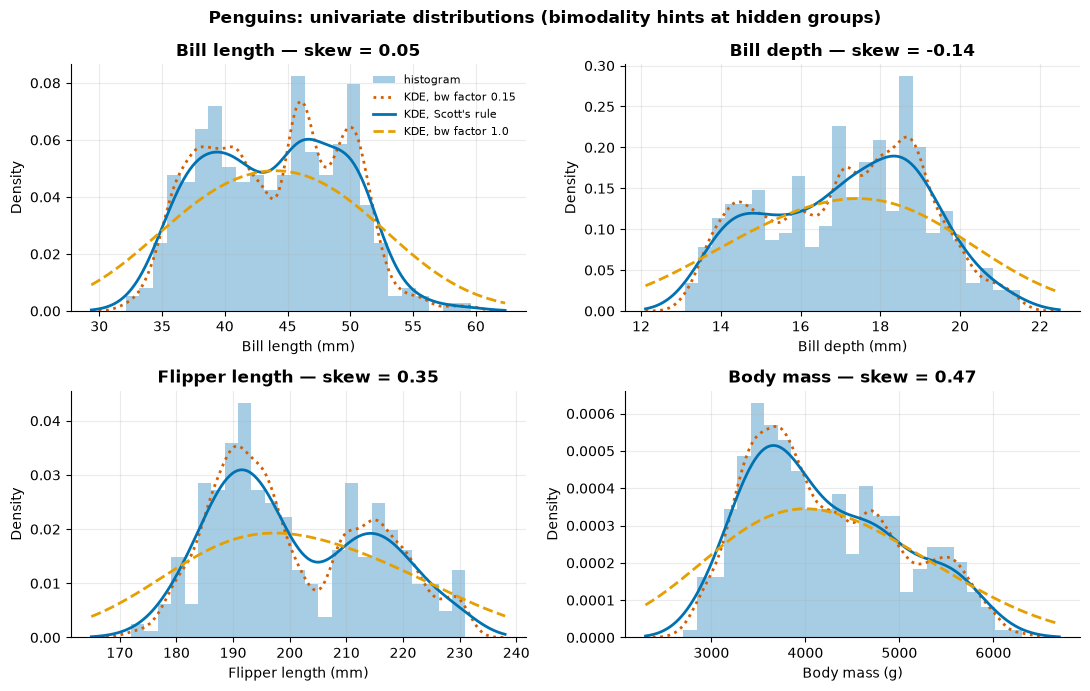

In [4]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
units = {"bill_length_mm": "Bill length (mm)", "bill_depth_mm": "Bill depth (mm)",
         "flipper_length_mm": "Flipper length (mm)", "body_mass_g": "Body mass (g)"}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), num_cols):
    x = penguins[col].dropna()
    ax.hist(x, bins=25, density=True, color=PALETTE[0], alpha=0.35, label="histogram")
    grid = np.linspace(x.min() - 5 * x.std() / 10, x.max() + 5 * x.std() / 10, 300)
    for bw, c, ls in [(0.15, PALETTE[3], ":"), (None, PALETTE[0], "-"), (1.0, PALETTE[1], "--")]:
        kde = stats.gaussian_kde(x, bw_method=bw)
        lbl = "KDE, Scott's rule" if bw is None else f"KDE, bw factor {bw}"
        ax.plot(grid, kde(grid), color=c, ls=ls, lw=2, label=lbl)
    ax.set_xlabel(units[col])
    ax.set_ylabel("Density")
    ax.set_title(f"{units[col].split(' (')[0]} — skew = {x.skew():.2f}")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Penguins: univariate distributions (bimodality hints at hidden groups)", fontweight="bold")
fig.tight_layout()
savefig("univariate_hist_kde")
plt.show()

Bill length and flipper length are **bimodal** — a strong hint that the data mixes groups (species!).
The dotted KDE (small bandwidth) chases noise; the dashed one (large bandwidth) smooths the second mode away.

### 1.2 Box plots and violin plots

A **box plot** shows the median, quartiles (the box = IQR) and whiskers to the most extreme point within
1.5 IQR. A **violin plot** adds the KDE shape — it reveals multimodality that a box hides.

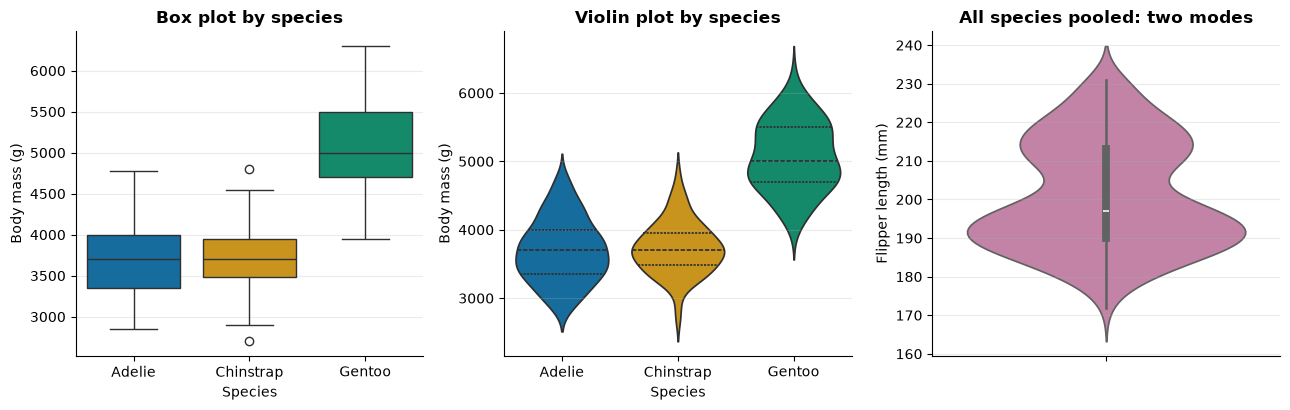

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
sns.boxplot(data=penguins, x="species", y="body_mass_g", hue="species", palette=SPECIES_COLORS, ax=axes[0])
axes[0].set_title("Box plot by species")
sns.violinplot(data=penguins, x="species", y="body_mass_g", hue="species", palette=SPECIES_COLORS,
               inner="quartile", ax=axes[1])
axes[1].set_title("Violin plot by species")
sns.violinplot(data=penguins, y="flipper_length_mm", ax=axes[2], color=PALETTE[4], inner="box")
axes[2].set_title("All species pooled: two modes")
for ax in axes[:2]:
    ax.set_xlabel("Species")
    ax.set_ylabel("Body mass (g)")
axes[2].set_ylabel("Flipper length (mm)")
fig.tight_layout()
savefig("box_violin")
plt.show()

### 1.3 Skewness and log transforms

Sample skewness $g_1 = \frac{\frac1n\sum (x_i-\bar x)^3}{s^3}$: 0 for symmetric data, > 0 for a long right
tail. Rules of thumb: $|g_1| < 0.5$ ≈ symmetric, $0.5$–$1$ moderate, $> 1$ strong. Right-skewed positive
quantities (sizes, prices, counts) often become more symmetric under $\log x$ — and multiplicative effects
become additive.

In [6]:
skew_table = pd.DataFrame({
    "skew (raw)": mpg[["mpg", "displacement", "horsepower", "weight", "acceleration"]].skew(),
    "skew (log)": np.log(mpg[["mpg", "displacement", "horsepower", "weight", "acceleration"]]).skew(),
}).round(2)
skew_table

,skew (raw),skew (log)
mpg,0.46,-0.14
displacement,0.72,0.23
horsepower,1.09,0.37
weight,0.53,0.16
acceleration,0.28,-0.36


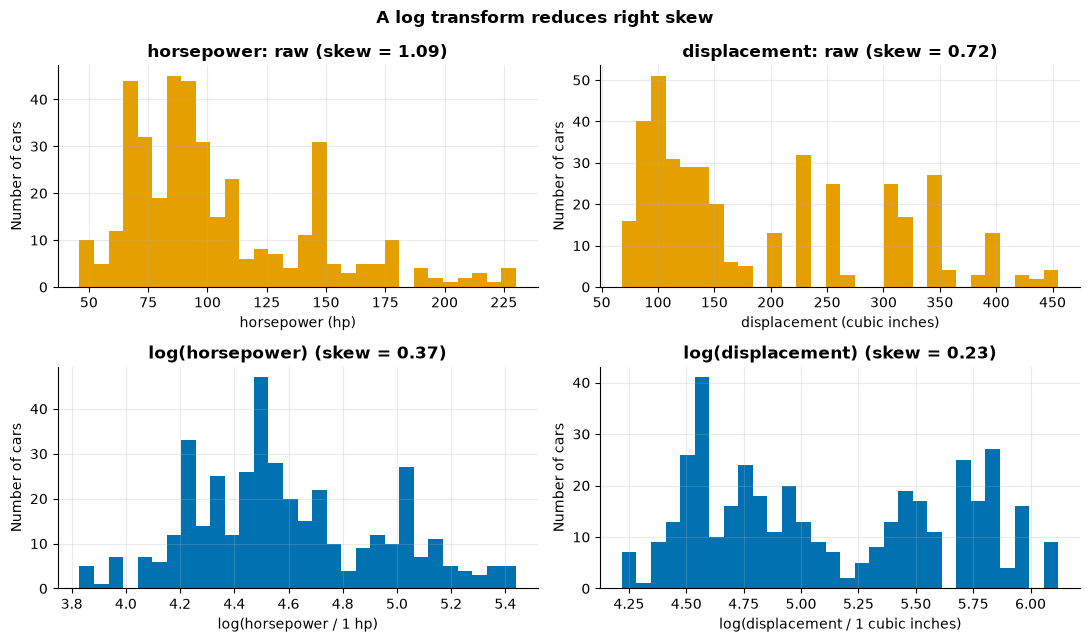

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for col, (ax_raw, ax_log), unit in [("horsepower", axes[:, 0], "hp"), ("displacement", axes[:, 1], "cubic inches")]:
    x = mpg[col].dropna()
    ax_raw.hist(x, bins=30, color=PALETTE[1])
    ax_raw.set_title(f"{col}: raw (skew = {x.skew():.2f})")
    ax_raw.set_xlabel(f"{col} ({unit})")
    ax_log.hist(np.log(x), bins=30, color=PALETTE[0])
    ax_log.set_title(f"log({col}) (skew = {np.log(x).skew():.2f})")
    ax_log.set_xlabel(f"log({col} / 1 {unit})")
    for ax in (ax_raw, ax_log):
        ax.set_ylabel("Number of cars")
fig.suptitle("A log transform reduces right skew", fontweight="bold")
fig.tight_layout()
savefig("skew_log_transform")
plt.show()

`displacement` stays multimodal after the log: its modes correspond to engine families (4, 6, 8
cylinders). A transform fixes skew, not mixtures.

### 1.4 Categorical variables: counts

In [8]:
for col in ["species", "island", "sex"]:
    print(penguins[col].value_counts(dropna=False).to_dict())
print(mpg["cylinders"].value_counts().sort_index().to_dict())

{'Adelie': 152, 'Gentoo': 124, 'Chinstrap': 68}
{'Biscoe': 168, 'Dream': 124, 'Torgersen': 52}
{'MALE': 168, 'FEMALE': 165, nan: 11}
{3: 4, 4: 204, 5: 3, 6: 84, 8: 103}


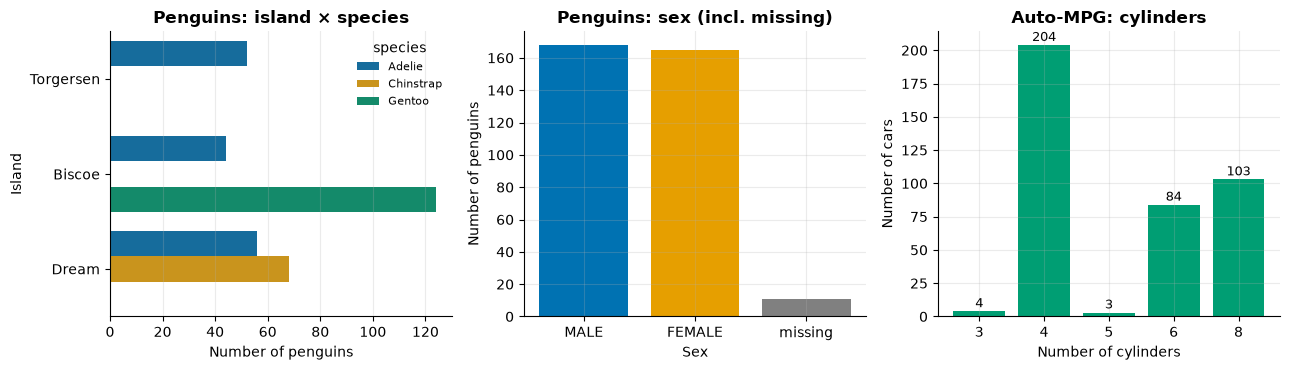

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
sns.countplot(data=penguins, y="island", hue="species", palette=SPECIES_COLORS, ax=axes[0])
axes[0].set_title("Penguins: island × species")
axes[0].set_xlabel("Number of penguins")
axes[0].set_ylabel("Island")
axes[0].legend(title="species", fontsize=8)
sex_counts = penguins["sex"].fillna("missing").value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=[PALETTE[0], PALETTE[1], "grey"])
axes[1].set_title("Penguins: sex (incl. missing)")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Number of penguins")
cyl = mpg["cylinders"].value_counts().sort_index()
axes[2].bar(cyl.index.astype(str), cyl.values, color=PALETTE[2])
for i, v in enumerate(cyl.values):
    axes[2].text(i, v + 3, str(v), ha="center", fontsize=9)
axes[2].set_title("Auto-MPG: cylinders")
axes[2].set_xlabel("Number of cylinders")
axes[2].set_ylabel("Number of cars")
fig.tight_layout()
savefig("categorical_counts")
plt.show()

Two things a model would never tell you: Chinstraps live only on Dream and Gentoos only on Biscoe
(so `island` is partly a proxy for species), and 3- and 5-cylinder cars are so rare (4 and 3 cars) that
any per-category statistic for them is unreliable — consider merging rare levels.

## 2. Bivariate analysis

### 2.1 Pair plot

A pair plot shows every pairwise scatter plot plus the univariate distributions on the diagonal.
Colouring by a categorical variable often explains the structure seen above.

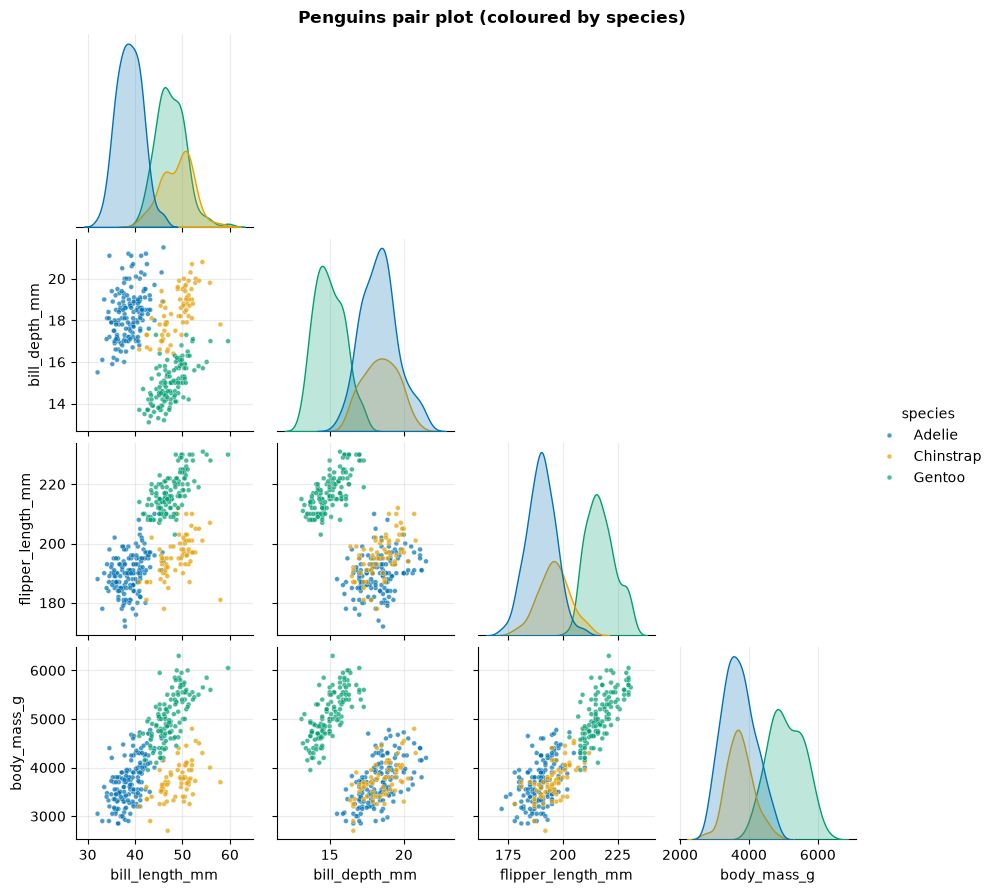

In [10]:
g = sns.pairplot(penguins.dropna(subset=num_cols), vars=num_cols, hue="species", palette=SPECIES_COLORS,
                 corner=True, plot_kws=dict(s=12, alpha=0.7), height=2.2)
g.figure.suptitle("Penguins pair plot (coloured by species)", fontweight="bold", y=1.01)
savefig("pairplot_penguins", fig=g.figure)
plt.show()

The two modes of bill length and flipper length are the species. Gentoos separate from the others on
almost every pair; Adelie vs Chinstrap separate mainly on bill length.

## 3. Correlation

**Pearson** measures *linear* association:

$$r = \frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum_i (x_i-\bar x)^2}\sqrt{\sum_i (y_i-\bar y)^2}}.$$

**Spearman** $\rho$ is Pearson applied to the *ranks* — it measures any *monotonic* association and is
robust to outliers. A large gap $|\rho| - |r|$ signals a curved but monotonic relationship.

In [11]:
mpg_num = mpg[["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]]
pearson = mpg_num.corr(method="pearson")
spearman = mpg_num.corr(method="spearman")
print("correlation with mpg:")
print(pd.DataFrame({"pearson": pearson["mpg"], "spearman": spearman["mpg"]}).drop("mpg").round(3))

correlation with mpg:
              pearson  spearman
cylinders      -0.775    -0.822
displacement   -0.804    -0.856
horsepower     -0.778    -0.854
weight         -0.832    -0.875
acceleration    0.420     0.439
model_year      0.579     0.573


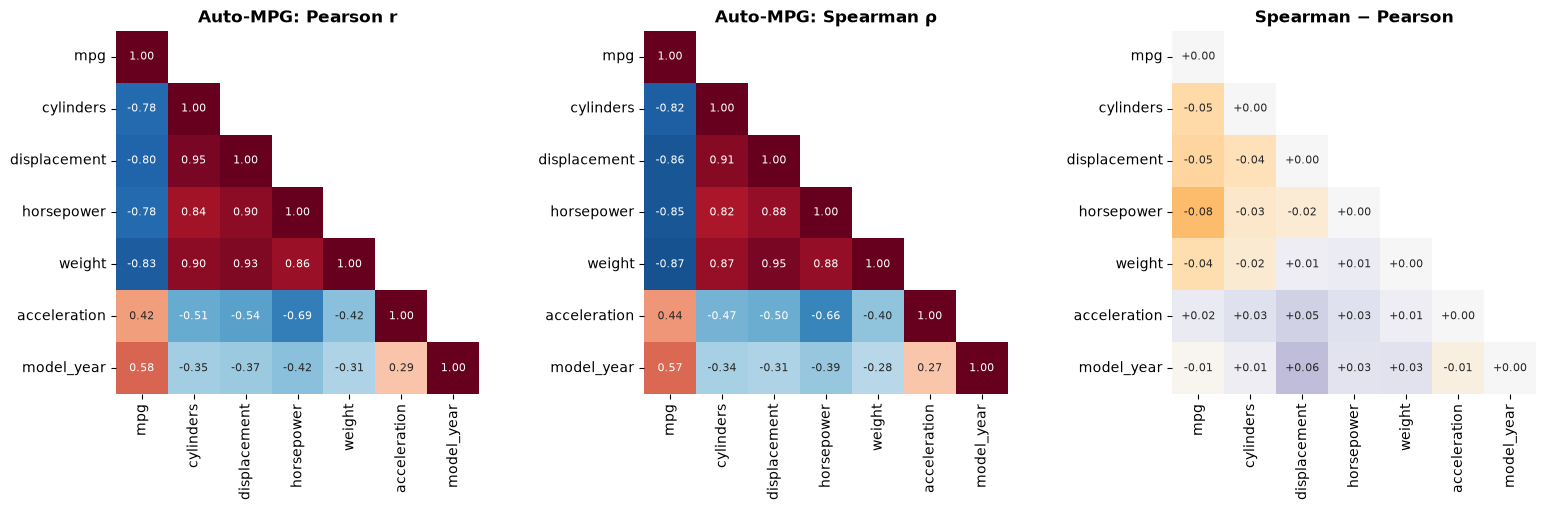

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1, 1]})
mask = np.triu(np.ones_like(pearson, dtype=bool), k=1)
for ax, mat, title in [(axes[0], pearson, "Pearson r"), (axes[1], spearman, "Spearman ρ")]:
    sns.heatmap(mat, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
                cbar=False, ax=ax, annot_kws={"size": 8})
    ax.set_title(f"Auto-MPG: {title}")
diff = spearman - pearson
sns.heatmap(diff, mask=mask, annot=True, fmt="+.2f", cmap="PuOr", vmin=-0.2, vmax=0.2, square=True,
            cbar=False, ax=axes[2], annot_kws={"size": 8})
axes[2].set_title("Spearman − Pearson")
for ax in axes:
    ax.grid(False)
fig.tight_layout()
savefig("correlation_heatmaps")
plt.show()

`mpg` vs `horsepower` / `displacement` / `weight`: Spearman is stronger than Pearson because the
relationship is monotonic but curved (a hyperbola-like decay). A linear model on raw features will
under-fit this; a transform (e.g. $1/\text{mpg}$ or $\log$) or a non-linear model will help (chapter 04–05).

### 3.1 Always plot: Anscombe's quartet

Anscombe (1973) built four datasets with (nearly) identical means, variances, correlation and regression
line — and completely different stories.

In [13]:
anscombe = pd.DataFrame({
    "x1": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
    "y1": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
    "y2": [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
    "y3": [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
    "x4": [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
    "y4": [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89],
})
sets = {"I": ("x1", "y1"), "II": ("x1", "y2"), "III": ("x1", "y3"), "IV": ("x4", "y4")}
summary = pd.DataFrame({
    name: {"mean x": anscombe[xc].mean(), "mean y": anscombe[yc].mean(), "var x": anscombe[xc].var(),
           "var y": anscombe[yc].var(), "pearson r": anscombe[xc].corr(anscombe[yc]),
           "slope": np.polyfit(anscombe[xc], anscombe[yc], 1)[0],
           "intercept": np.polyfit(anscombe[xc], anscombe[yc], 1)[1]}
    for name, (xc, yc) in sets.items()
}).round(2)
summary

,I,II,III,IV
mean x,9.00,9.00,9.00,9.00
mean y,7.50,7.50,7.50,7.50
var x,11.00,11.00,11.00,11.00
var y,4.13,4.13,4.12,4.12
pearson r,0.82,0.82,0.82,0.82
slope,0.50,0.50,0.50,0.50
intercept,3.00,3.00,3.00,3.00


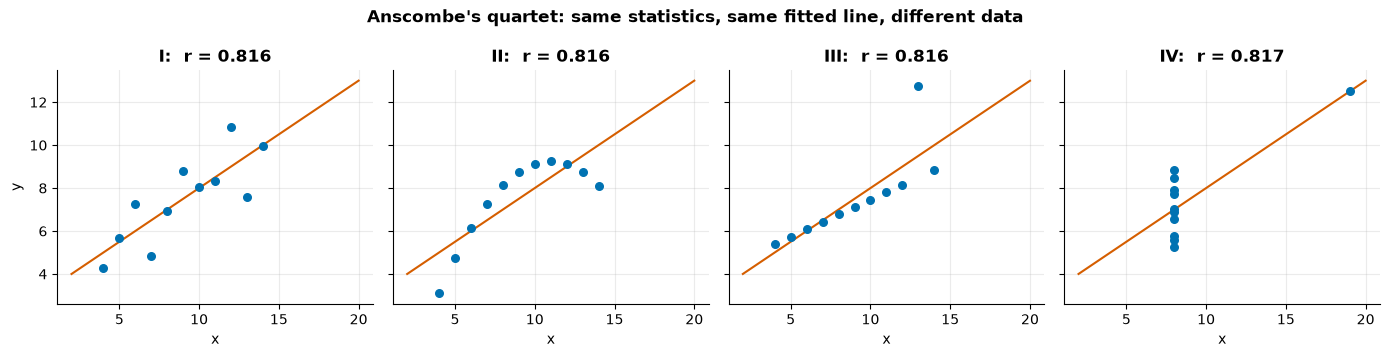

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharex=True, sharey=True)
xs = np.array([2, 20])
for ax, (name, (xc, yc)) in zip(axes, sets.items()):
    b, a = np.polyfit(anscombe[xc], anscombe[yc], 1)
    ax.scatter(anscombe[xc], anscombe[yc], color=PALETTE[0], s=30, zorder=3)
    ax.plot(xs, a + b * xs, color=PALETTE[3], lw=1.5)
    ax.set_title(f"{name}:  r = {anscombe[xc].corr(anscombe[yc]):.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.suptitle("Anscombe's quartet: same statistics, same fitted line, different data", fontweight="bold")
fig.tight_layout()
savefig("anscombe_quartet")
plt.show()

I is a noisy linear relation; II is a clean curve; III is linear with one outlier; IV has no relation at
all except one high-leverage point. Summary statistics alone would treat them identically.

### 3.2 Correlation ≠ causation, and Simpson's paradox

A correlation between $X$ and $Y$ can arise because $X \to Y$, $Y \to X$, a **confounder** $Z$ drives both,
or by selection/chance. **Simpson's paradox** is the extreme case: a trend in the pooled data *reverses*
inside every subgroup. Penguins show it for bill length vs bill depth.

In [15]:
p = penguins.dropna(subset=["bill_length_mm", "bill_depth_mm"])
groups = {"all species pooled": p, **dict(tuple(p.groupby("species")))}
rows = []
for name, grp in groups.items():
    r = stats.pearsonr(grp["bill_length_mm"], grp["bill_depth_mm"])
    slope = np.polyfit(grp["bill_length_mm"], grp["bill_depth_mm"], 1)[0]
    rows.append({"group": name, "n": len(grp), "pearson r": round(r.statistic, 3),
                 "p-value": f"{r.pvalue:.1e}", "slope (mm per mm)": round(slope, 3)})
pd.DataFrame(rows).set_index("group")

,n,pearson r,p-value,slope (mm per mm)
group,,,,
all species pooled,342,-0.235,1.1e-05,-0.085
Adelie,151,0.391,6.7e-07,0.179
Chinstrap,68,0.654,1.5e-09,0.222
Gentoo,123,0.643,1.0e-15,0.205


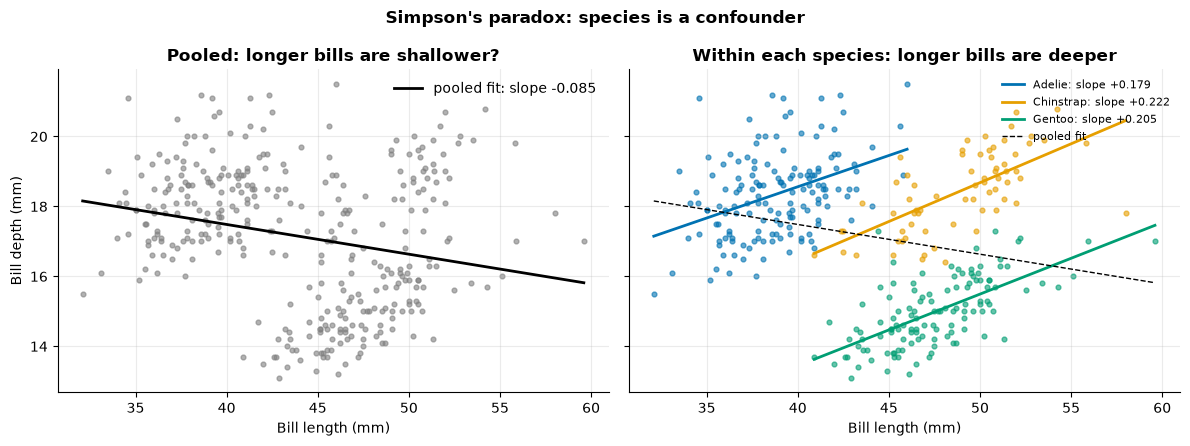

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
xs = np.linspace(p["bill_length_mm"].min(), p["bill_length_mm"].max(), 50)
b, a = np.polyfit(p["bill_length_mm"], p["bill_depth_mm"], 1)
axes[0].scatter(p["bill_length_mm"], p["bill_depth_mm"], s=12, color="grey", alpha=0.6)
axes[0].plot(xs, a + b * xs, color="k", lw=2, label=f"pooled fit: slope {b:+.3f}")
axes[0].set_title("Pooled: longer bills are shallower?")
axes[0].legend(loc="upper right")
for sp, grp in p.groupby("species"):
    c = SPECIES_COLORS[sp]
    axes[1].scatter(grp["bill_length_mm"], grp["bill_depth_mm"], s=12, color=c, alpha=0.6)
    bs, as_ = np.polyfit(grp["bill_length_mm"], grp["bill_depth_mm"], 1)
    xg = np.linspace(grp["bill_length_mm"].min(), grp["bill_length_mm"].max(), 20)
    axes[1].plot(xg, as_ + bs * xg, color=c, lw=2, label=f"{sp}: slope {bs:+.3f}")
axes[1].plot(xs, a + b * xs, color="k", lw=1, ls="--", label="pooled fit")
axes[1].set_title("Within each species: longer bills are deeper")
axes[1].legend(loc="upper right", fontsize=8)
for ax in axes:
    ax.set_xlabel("Bill length (mm)")
axes[0].set_ylabel("Bill depth (mm)")
fig.suptitle("Simpson's paradox: species is a confounder", fontweight="bold")
fig.tight_layout()
savefig("simpsons_paradox")
plt.show()

Pooled, the correlation is negative; within every species it is clearly positive. Species drives both
variables (Gentoos have long but shallow bills). A model or an analyst that ignores the confounder draws
the opposite conclusion. **Always ask: which variable could be driving both?**

## 4. Target analysis

Now we act like a real project: split first, explore the **training set**.

In [17]:
mpg_train, mpg_test = train_test_split(mpg, test_size=0.2, random_state=RANDOM_STATE)
pen = penguins.dropna(subset=num_cols)
pen_train, pen_test = train_test_split(pen, test_size=0.2, stratify=pen["species"], random_state=RANDOM_STATE)
print(f"mpg train: {len(mpg_train)} rows, penguins train: {len(pen_train)} rows")
print("\nmpg target summary (train):")
print(mpg_train["mpg"].describe().round(2).to_dict(), f"skew={mpg_train['mpg'].skew():.2f}")
print("\npenguin class balance (train):")
print(pen_train["species"].value_counts(normalize=True).round(3).to_dict())

print(f"skew of the same target as consumption, 235.215/mpg (L/100 km): {(235.215 / mpg_train['mpg']).skew():.2f}")

mpg train: 318 rows, penguins train: 273 rows

mpg target summary (train):
{'count': 318.0, 'mean': 23.61, 'std': 7.93, 'min': 9.0, '25%': 17.5, '50%': 22.45, '75%': 29.72, 'max': 46.6} skew=0.47

penguin class balance (train):
{'Adelie': 0.443, 'Gentoo': 0.359, 'Chinstrap': 0.198}
skew of the same target as consumption, 235.215/mpg (L/100 km): 0.73


The mpg target is mildly right-skewed (0.47); expressed as consumption (L/100 km) it is even more
right-skewed (0.73) — the scale you choose changes the shape. Which scale to model is a framing decision (chapter 01): consumption is what a fuel bill is
proportional to. The penguin classes are moderately imbalanced (Chinstrap ≈ 20 %) — use stratified splits
and look at per-class metrics, not only accuracy.

### 4.1 Target distribution and feature vs target

Top row: the regression target and its relation to three features. Bottom row: the classification
target's balance and per-class distributions of three features.

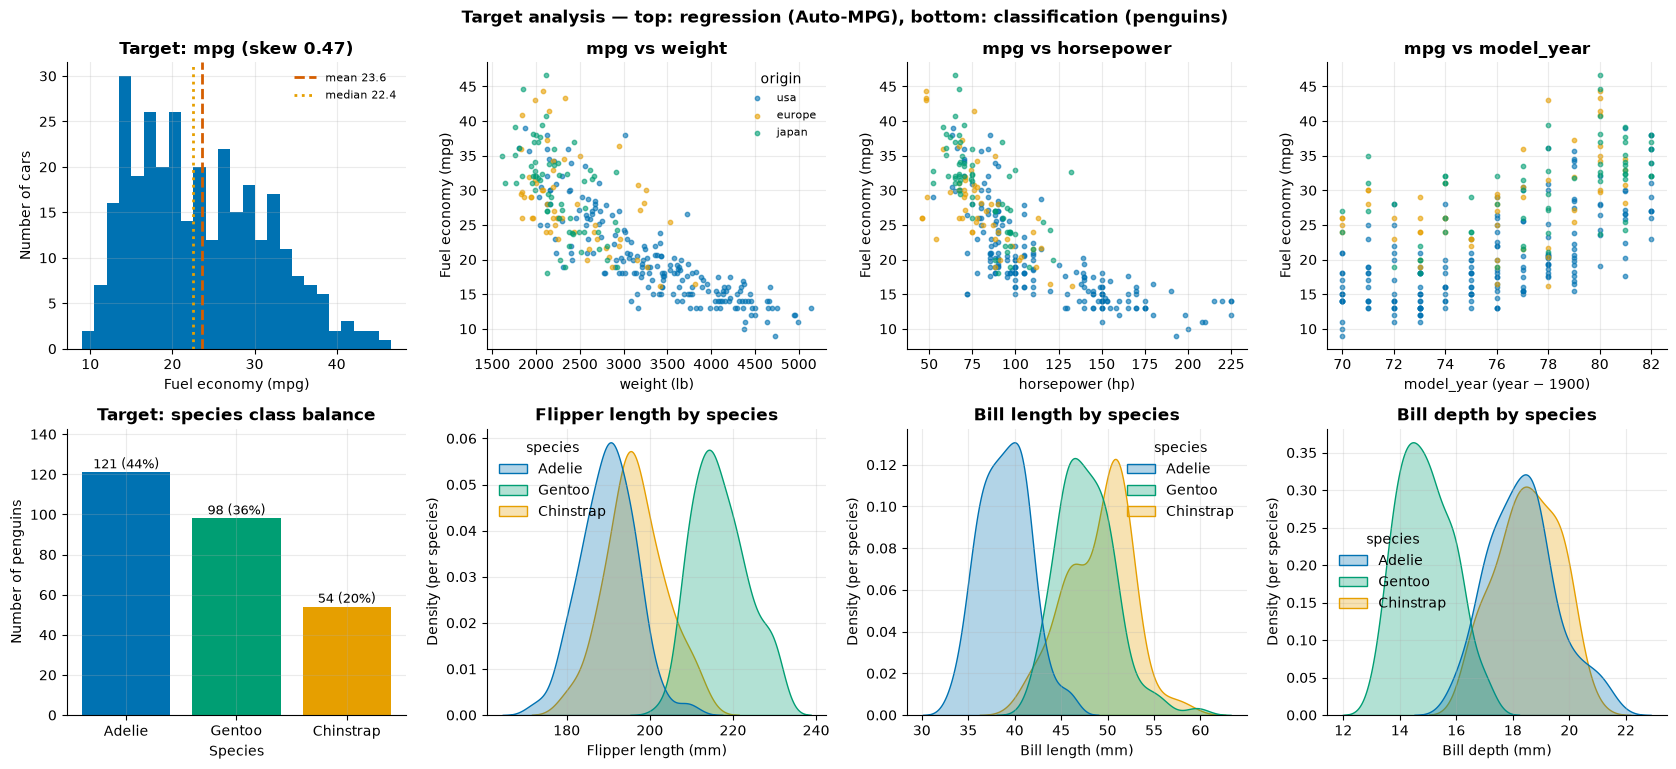

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7.8))
ax = axes[0, 0]
ax.hist(mpg_train["mpg"], bins=25, color=PALETTE[0])
ax.axvline(mpg_train["mpg"].mean(), color=PALETTE[3], ls="--", lw=2, label=f"mean {mpg_train['mpg'].mean():.1f}")
ax.axvline(mpg_train["mpg"].median(), color=PALETTE[1], ls=":", lw=2, label=f"median {mpg_train['mpg'].median():.1f}")
ax.set_xlabel("Fuel economy (mpg)")
ax.set_ylabel("Number of cars")
ax.set_title(f"Target: mpg (skew {mpg_train['mpg'].skew():.2f})")
ax.legend(fontsize=8)
for ax, col, unit in zip(axes[0, 1:], ["weight", "horsepower", "model_year"], ["lb", "hp", "year − 1900"]):
    for o, c in zip(["usa", "europe", "japan"], PALETTE):
        sel = mpg_train["origin"] == o
        ax.scatter(mpg_train.loc[sel, col], mpg_train.loc[sel, "mpg"], s=10, alpha=0.6, color=c, label=o)
    ax.set_xlabel(f"{col} ({unit})")
    ax.set_ylabel("Fuel economy (mpg)")
    ax.set_title(f"mpg vs {col}")
axes[0, 1].legend(title="origin", fontsize=8)
ax = axes[1, 0]
counts = pen_train["species"].value_counts()
ax.bar(counts.index, counts.values, color=[SPECIES_COLORS[s] for s in counts.index])
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, f"{v} ({v / counts.sum():.0%})", ha="center", fontsize=9)
ax.set_ylim(0, counts.max() * 1.18)
ax.set_xlabel("Species")
ax.set_ylabel("Number of penguins")
ax.set_title("Target: species class balance")
for ax, col in zip(axes[1, 1:], ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]):
    sns.kdeplot(data=pen_train, x=col, hue="species", palette=SPECIES_COLORS, fill=True, alpha=0.3,
                common_norm=False, ax=ax)
    ax.set_xlabel(units[col])
    ax.set_ylabel("Density (per species)")
    ax.set_title(f"{units[col].split(' (')[0]} by species")
fig.suptitle("Target analysis — top: regression (Auto-MPG), bottom: classification (penguins)", fontweight="bold")
fig.tight_layout()
savefig("target_analysis")
plt.show()

- `mpg` falls with weight and horsepower (curved), rises with model year (technology + regulation).
- Flipper length separates Gentoo; bill length separates Adelie from the rest; bill depth separates Gentoo.
  No single feature separates all three species — combinations will be needed.


### 4.2 Mutual information

Correlation only sees linear (Pearson) or monotonic (Spearman) relationships, and needs numeric targets.
**Mutual information** measures *any* dependence:

$$I(X;Y) = \iint p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)}\,dx\,dy \;\ge 0,$$

zero if and only if $X$ and $Y$ are independent. scikit-learn estimates it with a k-nearest-neighbour
estimator (Kraskov et al. 2004; Ross 2014), in nats.

In [19]:
feat_mpg = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
tr = mpg_train.dropna(subset=feat_mpg)
mi_reg = mutual_info_regression(tr[feat_mpg], tr["mpg"], discrete_features=[True, False, False, False, False, True],
                                random_state=RANDOM_STATE)
mi_mpg = pd.DataFrame({"mutual info (nats)": mi_reg,
                       "|pearson r|": tr[feat_mpg].corrwith(tr["mpg"]).abs().to_numpy(),
                       "|spearman ρ|": tr[feat_mpg].corrwith(tr["mpg"], method="spearman").abs().to_numpy()},
                      index=feat_mpg).sort_values("mutual info (nats)", ascending=False).round(3)
mi_cls = pd.Series(mutual_info_classif(pen_train[num_cols], pen_train["species"], random_state=RANDOM_STATE),
                   index=num_cols).sort_values(ascending=False).round(3)
display(mi_mpg)
display(mi_cls.to_frame("mutual info with species (nats)"))

,mutual info (nats),|pearson r|,|spearman ρ|
displacement,0.757,0.803,0.850
weight,0.739,0.828,0.870
horsepower,0.710,0.772,0.849
cylinders,0.650,0.773,0.820
model_year,0.335,0.589,0.596
acceleration,0.146,0.393,0.414


,mutual info with species (nats)
flipper_length_mm,0.643
bill_depth_mm,0.594
bill_length_mm,0.586
body_mass_g,0.509


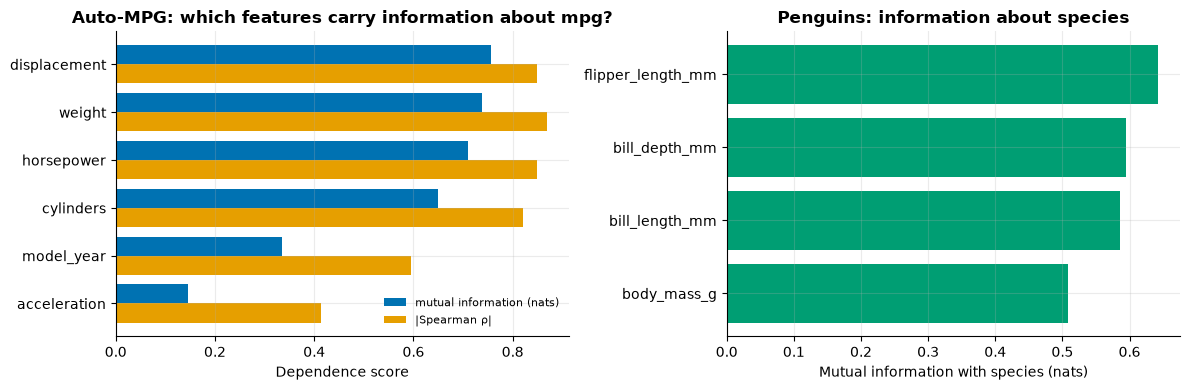

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y = np.arange(len(mi_mpg))
axes[0].barh(y - 0.2, mi_mpg["mutual info (nats)"], height=0.4, color=PALETTE[0], label="mutual information (nats)")
axes[0].barh(y + 0.2, mi_mpg["|spearman ρ|"], height=0.4, color=PALETTE[1], label="|Spearman ρ|")
axes[0].set_yticks(y, mi_mpg.index)
axes[0].invert_yaxis()
axes[0].set_xlabel("Dependence score")
axes[0].set_title("Auto-MPG: which features carry information about mpg?")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].barh(mi_cls.index, mi_cls.values, color=PALETTE[2])
axes[1].invert_yaxis()
axes[1].set_xlabel("Mutual information with species (nats)")
axes[1].set_title("Penguins: information about species")
fig.tight_layout()
savefig("mutual_information")
plt.show()

MI and rank correlation broadly agree for mpg (the top four features are nearly tied in both); MI additionally works for a categorical target
where correlation is undefined. MI is *univariate* — it cannot see interactions or redundancy (weight,
displacement and horsepower carry largely the *same* information). It is a screening tool, not a verdict.

## 5. An EDA checklist

| Step | Questions | Tools |
|---|---|---|
| Structure | rows, columns, dtypes, ID column, time column? | `df.info()`, `df.head()` |
| Missingness | how much, where, why (MCAR/MAR/MNAR)? | `isna().mean()`, missingness matrix |
| Univariate numeric | range, skew, modes, impossible values | histogram + KDE, box/violin, `describe()` |
| Univariate categorical | levels, rare levels, spelling variants | `value_counts(dropna=False)` |
| Target | distribution, skew, class balance, scale choice | histogram, bar chart |
| Feature vs target | shape of relationship (linear? monotone? thresholds?) | scatter, grouped KDE/box |
| Feature vs feature | redundancy, collinearity, clusters | pair plot, Pearson + Spearman heatmaps |
| Confounders | could a third variable explain a pattern? | colour/facet by groups (Simpson) |
| Leakage smell | a feature *too* good to be true? | MI / correlation ranking, domain check |
| Write it down | hypotheses for feature engineering and model choice | a short notes cell |

## Key takeaways

- Start with structure and missingness, then **univariate → bivariate → target**.
- Histograms + KDE reveal skew and **multimodality**; multimodality usually means hidden groups.
- Right-skewed positive variables often look better on a **log scale**.
- **Pearson** = linear, **Spearman** = monotonic; compare both. And **always plot** (Anscombe).
- A pooled trend can reverse within groups (**Simpson's paradox**): look for confounders before
  interpreting any correlation causally.
- **Mutual information** screens for any (univariate) dependence, including with categorical targets.
- Do EDA that informs modelling decisions on the **training set**.

## Exercises

1. **Bandwidth.** Plot KDEs of `body_mass_g` for bandwidth factors 0.05, 0.2, 0.5, 1. Which one would you
   trust, and why? *Hint: compare with a histogram with many bins.*
2. **Transforms.** Compute Pearson r between `mpg` and `weight`, `log(weight)` and `1/weight`. Which is most
   linear? *Hint: physics suggests fuel consumption (1/mpg) is roughly proportional to weight.*
3. **Simpson in Auto-MPG.** Look at `mpg` vs `acceleration` pooled and per `cylinders` group. Does the sign
   change? *Hint: `groupby("cylinders")` and `corr`.*
4. **MI with noise.** Add a pure-noise column to the mpg features and recompute mutual information for
   several `random_state`s. How big is the MI of noise? *Hint: this gives you a rough "zero" level.*
5. **Your own checklist.** Apply the checklist to the Titanic data and write five hypotheses about survival.
   *Hint: start with `sex`, `pclass`, `age` and the missingness of `deck`.*